In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import duckdb
import seaborn as sns
font_scale = 7
sns.set_theme(style='whitegrid', font_scale=font_scale, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import seaborn as sns
import polars as pl
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from conf import conf
from dafm import plots

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

# Run queries

### Datasets

In [102]:
dataset_cols = ''.join(map(str.strip, """
    id,
    dataset_name,
    dataset_name_latex_short,
    state_dimension,
    state_dimension_latex,
    time_step_count,
    time_step_count_drop_first,
    observe_every_n_time_steps,
""".splitlines()))

In [107]:
dataset_rows = duckdb.sql(f"""
    select {dataset_cols} from paper_kuramoto_sivashinsky_classical_comparison
    union
    select {dataset_cols} from paper_navier_stokes_classical_comparison
""")
dataset_multiple = 6
assert len(dataset_rows) == dataset_multiple

### Models

In [108]:
model_cols = ''.join(map(str.strip, """
    id,
    model_name,
    hyperparameter1,
    hyperparameter1_name,
    hyperparameter2,
    hyperparameter2_name,
""".splitlines()))

In [109]:
sampling_time_step_counts = duckdb.sql("select 100")
topk_hyperparameters = duckdb.sql("""
    select
        *
    from read_csv('../sweeps/topk_hyperparameters_classical_comparison.csv')
    where true
    and k = 1
    and (
        sampling_time_step_count in (select * from sampling_time_step_counts)
        or
        sampling_time_step_count is null
    )
""")

In [110]:
duckdb.sql("""
select dataset_name, model_name, hyperparameter1, hyperparameter2 from topk_hyperparameters
where model_name in ('BPF', 'EnKF-PO', 'iEnKF-PO', 'ESRF', 'LETKF')
""")

┌─────────────────────┬────────────┬─────────────────┬─────────────────┐
│    dataset_name     │ model_name │ hyperparameter1 │ hyperparameter2 │
│       varchar       │  varchar   │     double      │     double      │
├─────────────────────┼────────────┼─────────────────┼─────────────────┤
│ KuramotoSivashinsky │ BPF        │             1.5 │            NULL │
│ KuramotoSivashinsky │ EnKF-PO    │             1.0 │             8.0 │
│ KuramotoSivashinsky │ iEnKF-PO   │             1.4 │            NULL │
│ KuramotoSivashinsky │ ESRF       │             1.0 │             8.0 │
│ KuramotoSivashinsky │ LETKF      │             1.0 │             8.0 │
│ NavierStokes        │ EnKF-PO    │             1.1 │             8.0 │
│ NavierStokes        │ iEnKF-PO   │             1.6 │            NULL │
│ NavierStokes        │ ESRF       │             1.7 │             8.0 │
│ NavierStokes        │ LETKF      │             1.0 │             6.0 │
└─────────────────────┴────────────┴───────────────

In [111]:
model_rows = duckdb.sql(rf"""
    select {model_cols} sampling_time_step_count from ensf
    union
    select {model_cols} sampling_time_step_count from enff_ot
    union
    select {model_cols} sampling_time_step_count from enff_f2p
    union
    select {model_cols} null as sampling_time_step_count from bpf
    union
    select {model_cols} null as sampling_time_step_count from enkf_po
    union
    select {model_cols} null as sampling_time_step_count from ienkf_po
    union
    select {model_cols} null as sampling_time_step_count from esrf
    union
    select {model_cols} null as sampling_time_step_count from letkf
""")
model_multiple = 8
assert duckdb.sql('select count(distinct model_name) from model_rows').fetchall()[0][0] == model_multiple

### General

In [112]:
rows = duckdb.sql("""
    select alt_id, rng_seed, dataset_rows.*, model_rows.*
    from Conf
    join dataset_rows on Conf.Dataset = dataset_rows.id
    join model_rows on Conf.Model = model_rows.id
    join topk_hyperparameters on (
        dataset_rows.dataset_name = topk_hyperparameters.dataset_name
        and
        model_rows.model_name = topk_hyperparameters.model_name
        and (
            model_rows.hyperparameter2 is null
            and
            topk_hyperparameters.hyperparameter2 is null
            and
            model_rows.hyperparameter1 = topk_hyperparameters.hyperparameter1
            or
            (model_rows.hyperparameter1, model_rows.hyperparameter2) == (topk_hyperparameters.hyperparameter1, topk_hyperparameters.hyperparameter2)
        )
    )
    where true
    and rng_seed in (select * from rng_seed_test)
    and (
        model_rows.sampling_time_step_count is null
        or
        model_rows.sampling_time_step_count in (select * from sampling_time_step_counts)
    )
""")
rng_seed_multiple = duckdb.sql("select count(*) from rng_seed_test").fetchall()[0][0]
multiple = (
    dataset_multiple
    * rng_seed_multiple
    * model_multiple
    - (dataset_multiple // 2 * rng_seed_multiple)  # BPF hyperparameter tuning fails for NavierStokes
)
assert len(rows) == multiple, f'{len(rows) = } != {multiple}'

In [113]:
duckdb.sql("""
    select
        dataset_name,
        model_name,
        count(*) as num_rows,
    from rows
    group by
        dataset_name,
        model_name,
    order by num_rows desc, dataset_name, model_name
""")

┌─────────────────────┬────────────┬──────────┐
│    dataset_name     │ model_name │ num_rows │
│       varchar       │  varchar   │  int64   │
├─────────────────────┼────────────┼──────────┤
│ KuramotoSivashinsky │ BPF        │       15 │
│ KuramotoSivashinsky │ ESRF       │       15 │
│ KuramotoSivashinsky │ EnFF-F2P   │       15 │
│ KuramotoSivashinsky │ EnFF-OT    │       15 │
│ KuramotoSivashinsky │ EnKF-PO    │       15 │
│ KuramotoSivashinsky │ EnSF       │       15 │
│ KuramotoSivashinsky │ LETKF      │       15 │
│ KuramotoSivashinsky │ iEnKF-PO   │       15 │
│ NavierStokes        │ ESRF       │       15 │
│ NavierStokes        │ EnFF-F2P   │       15 │
│ NavierStokes        │ EnFF-OT    │       15 │
│ NavierStokes        │ EnKF-PO    │       15 │
│ NavierStokes        │ EnSF       │       15 │
│ NavierStokes        │ LETKF      │       15 │
│ NavierStokes        │ iEnKF-PO   │       15 │
├─────────────────────┴────────────┴──────────┤
│ 15 rows                           3 co

In [114]:
logged_metrics_file_paths = plots.get_logged_metrics_file_paths(rows)
duckdb.sql("""
set variable dataset_metrics_filepaths = (
    select list(path) from logged_metrics_file_paths where exists
)
""")

##### RMSE and CRPS    

In [152]:
observation_steps_back = 50
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
    and step > time_step_count - observe_every_n_time_steps * {observation_steps_back}
""")
logged_metrics.show(max_width=125)

┌──────────┬───────────┬───────┬─────────────────────┬───┬──────────────────────┬────────────────────┬──────────────────────┐
│  alt_id  │ rng_seed  │  id   │    dataset_name     │ … │        time_s        │        crps        │         rmse         │
│ varchar  │   int64   │ int64 │       varchar       │   │        double        │       double       │        double        │
├──────────┼───────────┼───────┼─────────────────────┼───┼──────────────────────┼────────────────────┼──────────────────────┤
│ q6xeah2f │ 462133975 │    33 │ KuramotoSivashinsky │ … │  0.0030417859999971… │   32.1168404409273 │    2.020280464257174 │
│ q6xeah2f │ 462133975 │    33 │ KuramotoSivashinsky │ … │  0.0030488330000011… │  31.75087387845715 │   1.9973986688979288 │
│ q6xeah2f │ 462133975 │    33 │ KuramotoSivashinsky │ … │  0.0030514400000001… │  31.14186235895398 │   1.9595072355449619 │
│ q6xeah2f │ 462133975 │    33 │ KuramotoSivashinsky │ … │  0.0030351929999987… │ 30.806811862200288 │   1.93893679942

##### Time (seconds)

In [144]:
observation_steps_back = None
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
""")
logged_metrics.show(max_width=125)

┌──────────┬──────────┬───────┬─────────────────────┬───┬──────────────────────┬────────────────────┬──────────────────────┐
│  alt_id  │ rng_seed │  id   │    dataset_name     │ … │        time_s        │        crps        │         rmse         │
│ varchar  │  int64   │ int64 │       varchar       │   │        double        │       double       │        double        │
├──────────┼──────────┼───────┼─────────────────────┼───┼──────────────────────┼────────────────────┼──────────────────────┤
│ 1d9ayoa7 │ 19704671 │    33 │ KuramotoSivashinsky │ … │  0.13341936200000148 │  2.989983670659555 │  0.21643943429086485 │
│ 1d9ayoa7 │ 19704671 │    33 │ KuramotoSivashinsky │ … │  0.0033385869999982… │  3.533900514768877 │  0.24505579024910867 │
│ 1d9ayoa7 │ 19704671 │    33 │ KuramotoSivashinsky │ … │ 0.004750040000001121 │ 4.4658147740962875 │  0.30081097367091464 │
│ 1d9ayoa7 │ 19704671 │    33 │ KuramotoSivashinsky │ … │ 0.004803478000003025 │ 5.1797782665892305 │  0.34449791494977416 │


In [153]:
required_observation_step_count = duckdb.sql(f"""
    select
        dataset_name,
        state_dimension,
        max(observation_step_count) as required_observation_step_count,
    from (
        select
            dataset_name,
            state_dimension,
            count(*) as observation_step_count,
        from logged_metrics
        group by alt_id, dataset_name, state_dimension
    )
    group by dataset_name, state_dimension
""")
required_observation_step_count

┌─────────────────────┬─────────────────┬─────────────────────────────────┐
│    dataset_name     │ state_dimension │ required_observation_step_count │
│       varchar       │      int64      │              int64              │
├─────────────────────┼─────────────────┼─────────────────────────────────┤
│ NavierStokes        │          196608 │                              50 │
│ KuramotoSivashinsky │             512 │                              50 │
│ KuramotoSivashinsky │             256 │                              50 │
│ NavierStokes        │           12288 │                              50 │
│ NavierStokes        │             300 │                              50 │
│ KuramotoSivashinsky │            1024 │                              50 │
└─────────────────────┴─────────────────┴─────────────────────────────────┘

In [154]:
failed_before_finish_cols = """
    alt_id,
    dataset_name,
    state_dimension,
    model_name,
"""
failed_before_finish = duckdb.sql(f"""
    select
        observation_steps_back.*,
    from (
        select
            {failed_before_finish_cols}
            count(*) as observation_step_count,
        from logged_metrics
        group by {failed_before_finish_cols}
    ) as observation_steps_back
    join required_observation_step_count
    on observation_steps_back.dataset_name = required_observation_step_count.dataset_name
    and observation_steps_back.observation_step_count < required_observation_step_count.required_observation_step_count
    order by observation_steps_back.dataset_name, observation_steps_back.state_dimension, model_name desc, observation_step_count
""")
failed_before_finish

┌──────────┬──────────────┬─────────────────┬────────────┬────────────────────────┐
│  alt_id  │ dataset_name │ state_dimension │ model_name │ observation_step_count │
│ varchar  │   varchar    │      int64      │  varchar   │         int64          │
├──────────┼──────────────┼─────────────────┼────────────┼────────────────────────┤
│ diijx0ur │ NavierStokes │             300 │ iEnKF-PO   │                     10 │
│ diijx0ur │ NavierStokes │             300 │ iEnKF-PO   │                     10 │
│ diijx0ur │ NavierStokes │             300 │ iEnKF-PO   │                     10 │
│ o17onbdm │ NavierStokes │             300 │ iEnKF-PO   │                     20 │
│ o17onbdm │ NavierStokes │             300 │ iEnKF-PO   │                     20 │
│ o17onbdm │ NavierStokes │             300 │ iEnKF-PO   │                     20 │
│ 6n094py5 │ NavierStokes │             300 │ LETKF      │                     10 │
│ 6n094py5 │ NavierStokes │             300 │ LETKF      │                  

In [155]:
logged_metrics = duckdb.sql("""
    select *
    from logged_metrics
    where alt_id not in (select alt_id from failed_before_finish)
""")

In [156]:
duckdb.sql("""
    select
        model_name,
        state_dimension,
        count(*) as 'Num. Failed',
    from rows
    where
        alt_id not in (
            select alt_id from logged_metrics
        )
    group by model_name, state_dimension
    order by model_name desc, state_dimension
""")

┌────────────┬─────────────────┬─────────────┐
│ model_name │ state_dimension │ Num. Failed │
│  varchar   │      int64      │    int64    │
├────────────┼─────────────────┼─────────────┤
│ iEnKF-PO   │             256 │           2 │
│ iEnKF-PO   │             300 │           4 │
│ LETKF      │             256 │           2 │
│ LETKF      │             300 │           3 │
│ EnSF       │             256 │           2 │
│ EnSF       │             300 │           3 │
│ EnKF-PO    │             256 │           2 │
│ EnKF-PO    │             300 │           3 │
│ EnKF-PO    │          196608 │           5 │
│ EnFF-OT    │             256 │           2 │
│ EnFF-OT    │             300 │           3 │
│ EnFF-F2P   │             256 │           2 │
│ EnFF-F2P   │             300 │           3 │
│ ESRF       │             256 │           2 │
│ ESRF       │             300 │           3 │
├────────────┴─────────────────┴─────────────┤
│ 15 rows                          3 columns │
└────────────

In [157]:
group_by = """
    alt_id,
    rng_seed,
    dataset_name,
    dataset_name_latex_short,
    state_dimension,
    state_dimension_latex,
    model_name,
    sampling_time_step_count,
    hyperparameter1,
    hyperparameter1_name,
    hyperparameter2,
    hyperparameter2_name,
"""
logged_metrics_means = duckdb.sql(f"""
    select
        {group_by}
        mean(time_s) as time_s_mean,
        mean(rmse) as rmse,
        mean(crps) as crps,
    from logged_metrics
    group by
        {group_by}
""")
logged_metrics_means.show(max_width=125)

┌──────────┬───────────┬─────────────────────┬───┬──────────────────────┬──────────────────────┬────────────────────┐
│  alt_id  │ rng_seed  │    dataset_name     │ … │     time_s_mean      │         rmse         │        crps        │
│ varchar  │   int64   │       varchar       │   │        double        │        double        │       double       │
├──────────┼───────────┼─────────────────────┼───┼──────────────────────┼──────────────────────┼────────────────────┤
│ kijlyahp │ 462133975 │ KuramotoSivashinsky │ … │  0.21154309524000042 │  0.05856714787874427 │ 1.3128973517648002 │
│ tu20yyr8 │ 462133975 │ KuramotoSivashinsky │ … │   0.0707215723999991 │   1.8376866063731416 │ 29.091882128479675 │
│ nl21ew8y │ 979497033 │ NavierStokes        │ … │ 0.016572934200000732 │  0.06979225173592568 │  7.266477375030518 │
│ zhwayv45 │  97616566 │ NavierStokes        │ … │  0.46383988941999915 │  0.09604068443179131 │ 10.350279541015626 │
│ 0qvxjkyi │ 979497033 │ KuramotoSivashinsky │ … │  0.23

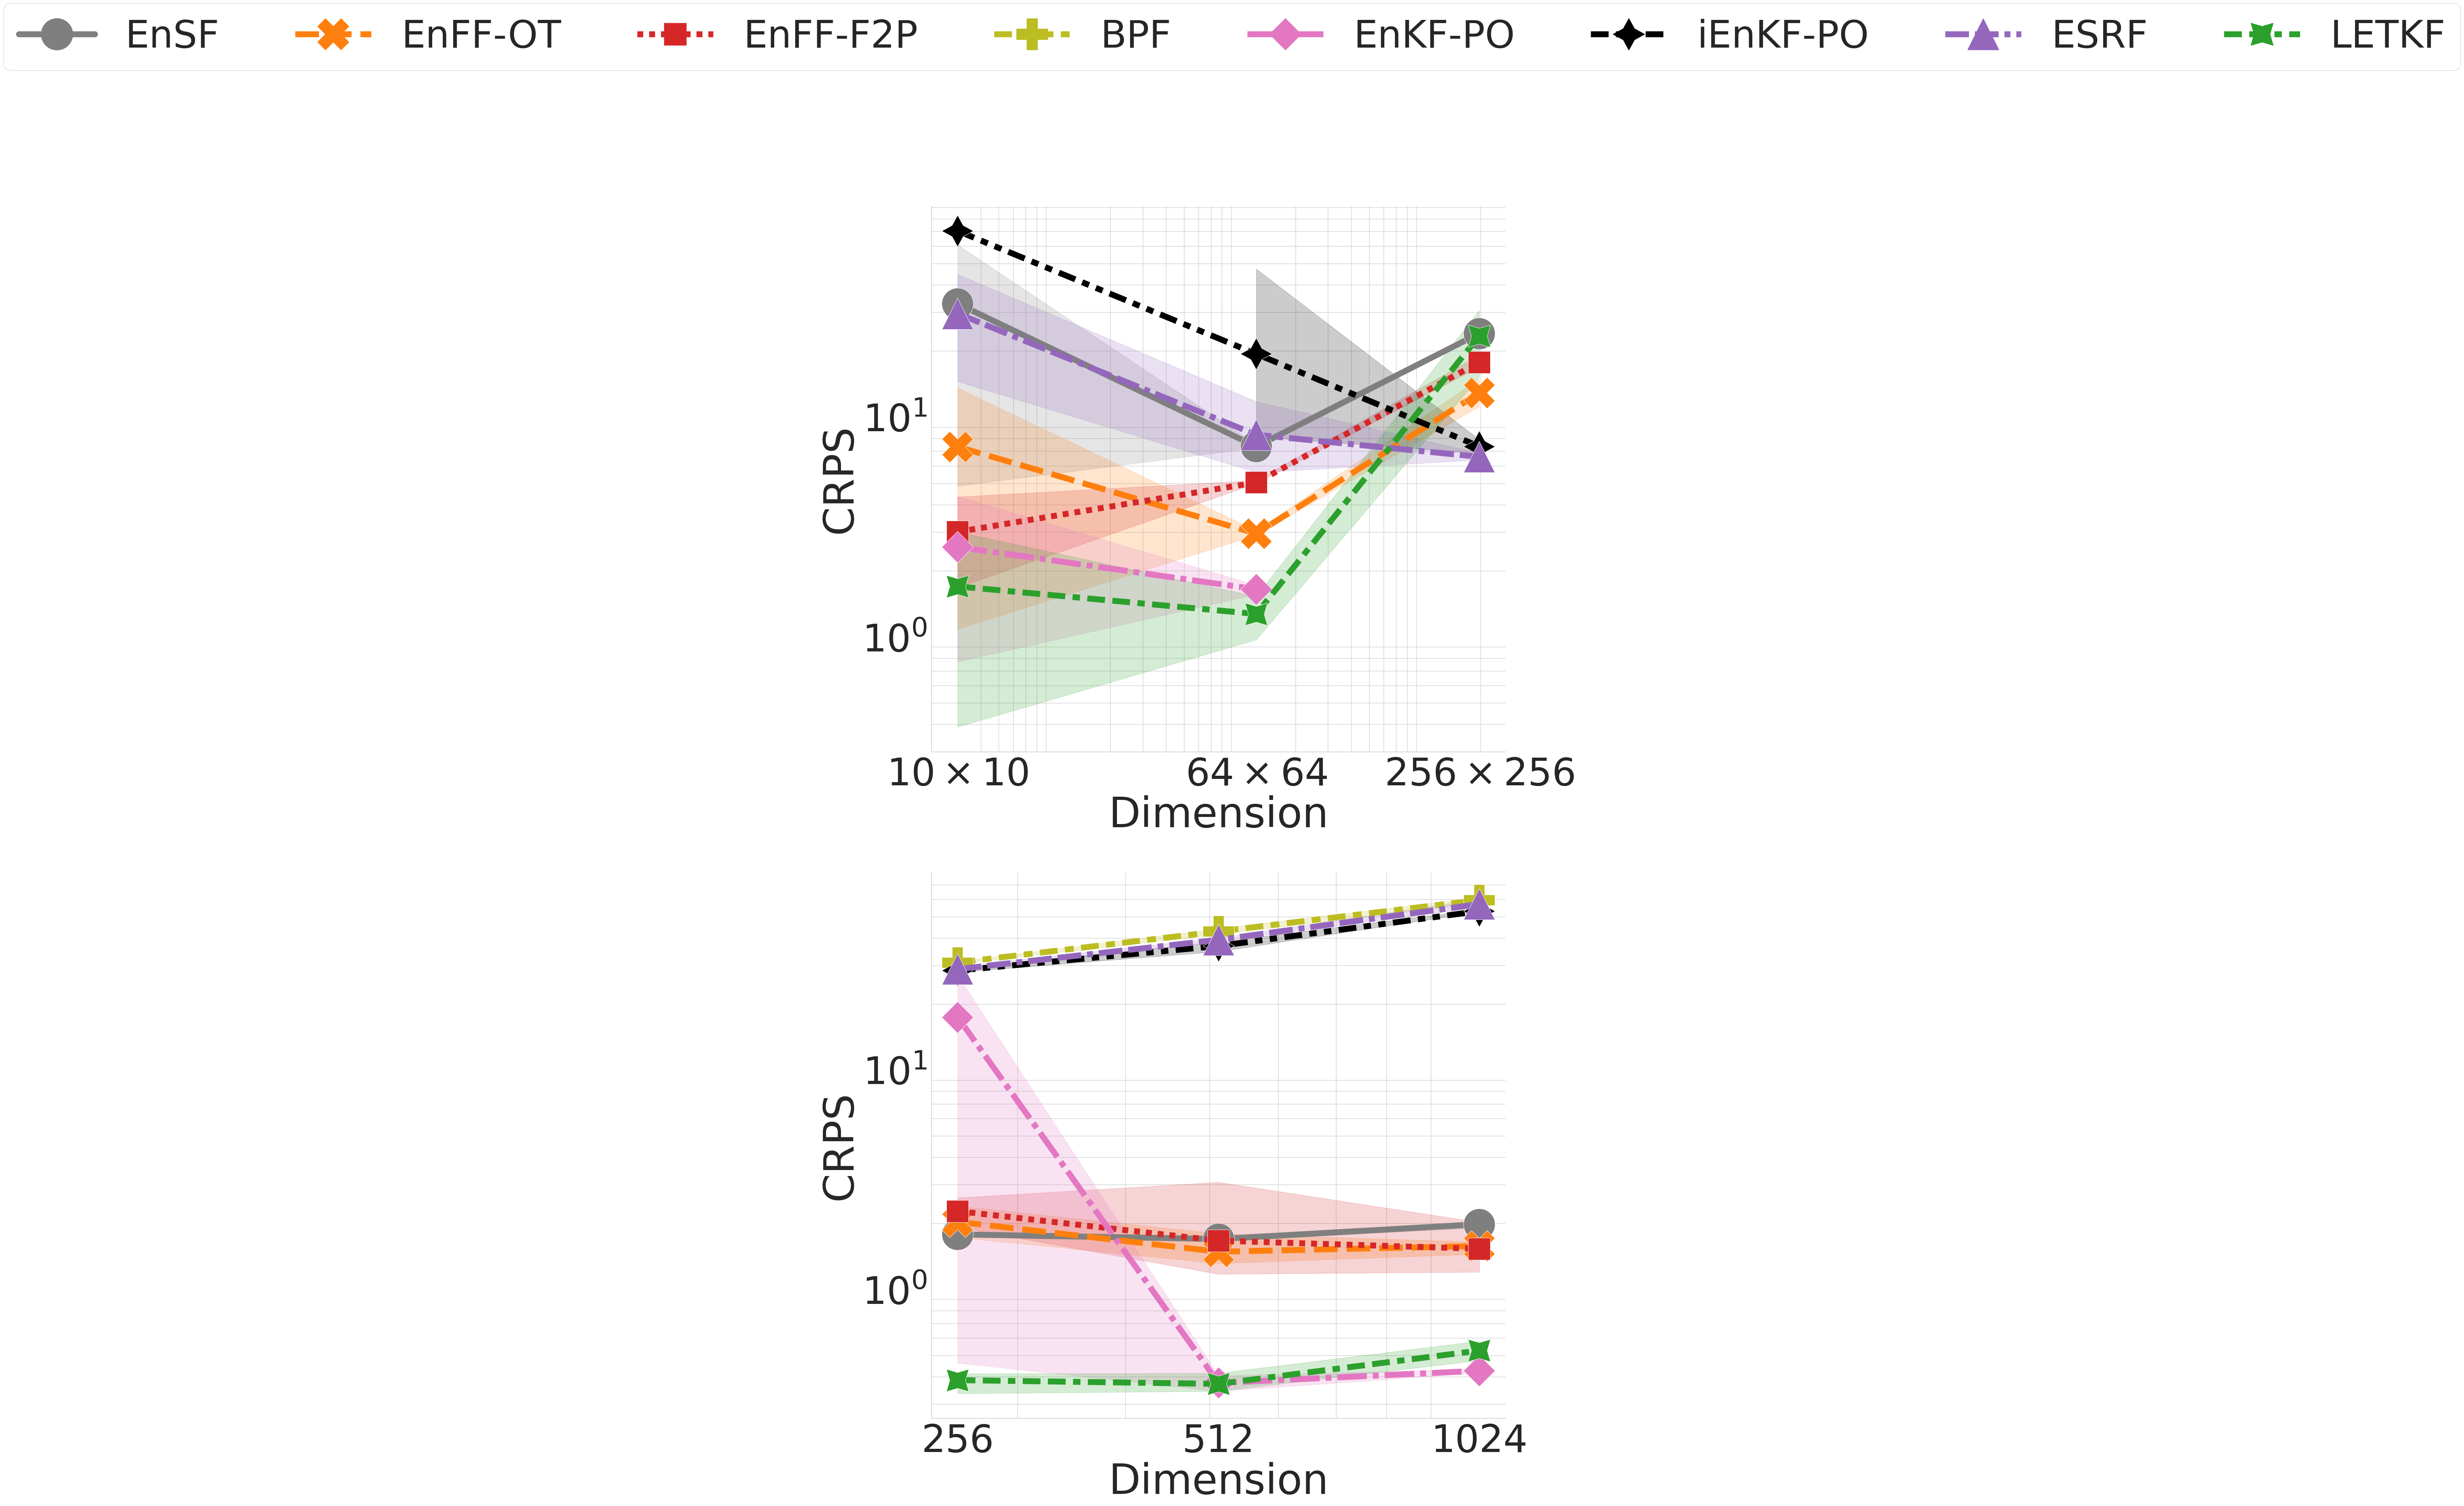

In [167]:
plot_data = logged_metrics_means.pl()
hue_order = sorted(plot_data['model_name'].unique(), key=plots.MODEL_ORDER.get)
y = 'crps'
plot_metric = (
    sns.relplot(
        kind='line',
        estimator='mean',
        errorbar=('pi', 100),
        data=plot_data,
        x='state_dimension',
        y=y,
        row='dataset_name',
        hue='model_name',
        hue_order=hue_order,
        style='model_name',
        style_order=hue_order,
        palette=plots.MODEL_PALETTE,
        markers=True,
        markersize=64,
        linewidth=12,
        height=20,
        aspect=1.1,
        facet_kws=dict(
            sharex=False,
            sharey=False,
        ),
    )
    .set(
        xscale='log',
        yscale='log',
        title='',
        xlabel='Dimension',
        ylabel=y.upper(),
        # ylabel='Time (s)',
    )
)
sns.move_legend(
    plot_metric,
    loc='upper center',
    ncol=len(hue_order),
    title='',
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)
for (row, col, hue), _ in plot_metric.facet_data():
    ax = plot_metric.axes[row, col]
    ax.grid()
    ax.grid(which='minor')
    dataset_name = plot_metric.row_names[row]
    xticks, xticklabels = (
        plot_data.filter(dataset_name=dataset_name)
        [['state_dimension', 'state_dimension_latex']]
        .unique()
        .sort('state_dimension')
    )
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    from matplotlib.ticker import FuncFormatter
    ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, pos: ''))
    # ax.minorticks_off()

In [168]:
plots.save_all_subfigures(plot_metric, y.upper())